# IEEE Fraud Detection – Precision-Optimized Pipeline with EDA
This notebook covers the end-to-end process of fraud detection, focusing on the specific business constraint: **False positives are extremely costly**. We will optimize for high Precision. We also include Exploratory Data Analysis (EDA) and basic Feature Engineering.

## 1. Install Dependencies

In [25]:
# Run this cell to install all required dependencies for the models and plotting
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

## 2. Import Libraries

In [26]:
import pandas as pd
import numpy as np
import warnings
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## 3. Data Loading & Merging

In [27]:
def load_and_merge_data():
    print("Loading datasets...")
    trans = pd.read_csv("train_transaction.csv")
    identity = pd.read_csv("train_identity.csv")
    
    print("Merging transaction and identity data...")
    data = trans.merge(identity, on="TransactionID", how="left")
    print(f"Merged dataset shape: {data.shape}")
    
    del trans, identity
    gc.collect()
    return data

merged_df = load_and_merge_data()

Loading datasets...
Merging transaction and identity data...
Merged dataset shape: (590540, 434)


## 4. Exploratory Data Analysis (EDA)

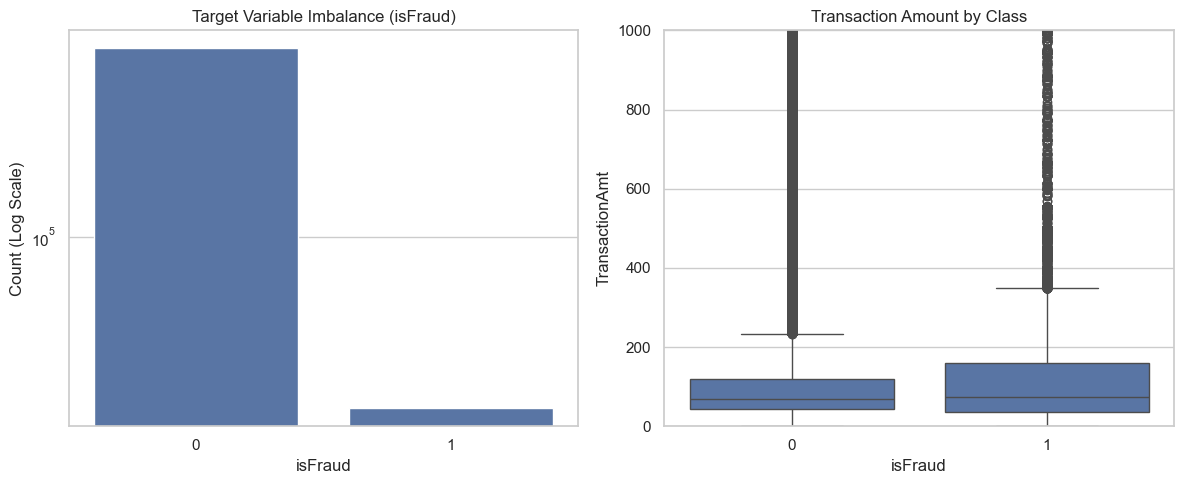

Percentage of Fraudulent Transactions: 3.50%


In [28]:
plt.figure(figsize=(12, 5))

# 1. Check Class Imbalance
plt.subplot(1, 2, 1)
sns.countplot(x='isFraud', data=merged_df)
plt.title('Target Variable Imbalance (isFraud)')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')

# 2. Transaction Amount by Fraud
plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='TransactionAmt', data=merged_df)
plt.title('Transaction Amount by Class')
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()

fraud_pct = merged_df['isFraud'].mean() * 100
print(f"Percentage of Fraudulent Transactions: {fraud_pct:.2f}%")

### 📌 Description: EDA Insights
The data is highly imbalanced, meaning traditional accuracy metrics will fail us. The boxplots also show that fraudulent transactions occasionally have different transaction amount distributions, making it a valuable basic feature.

## 5. Basic Interpretable Feature Engineering

In [29]:
def preprocess_and_engineer(data, is_train=True, label_encoders=None):
    print("Starting feature engineering...")
    data = data.copy()
    
    # --- Interpretable Feature Engineering ---
    # 1. Time Features: Business stakeholders understand "Time of Day" and "Day of Week" better than seconds from a start date.
    data['Transaction_Hour'] = (data['TransactionDT'] // 3600) % 24
    data['Transaction_Day'] = (data['TransactionDT'] // (3600 * 24)) % 7
    
    # 2. Decimal matching: Fraudsters often use exact dollar amounts without cents (e.g., $100.00 vs $100.42)
    data['Amt_is_Round'] = (data['TransactionAmt'] % 1 == 0).astype(int)
    
    # 3. Transaction Amount Deviation: Is this user suddenly spending way more than they usually do?
    if is_train:
        card_means = data.groupby('card1')['TransactionAmt'].mean().to_dict()
        data['card1_amt_mean'] = data['card1'].map(card_means)
    else:
        data['card1_amt_mean'] = data.groupby('card1')['TransactionAmt'].transform('mean')
        
    # Create a ratio: (Current Amount) / (Average Amount for this card)
    data['amt_vs_card1_mean'] = data['TransactionAmt'] / (data['card1_amt_mean'] + 0.01)
    # ---------------------------

    y = data["isFraud"] if "isFraud" in data.columns else None
    X = data.drop(["isFraud", "TransactionID", "card1_amt_mean"], axis=1, errors="ignore")

    # Feature Selection
    key_features = [
        'Transaction_Hour', 'Transaction_Day', 'Amt_is_Round', 'amt_vs_card1_mean',
        'TransactionDT', 'TransactionAmt', 'ProductCD',
        'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
        'addr1', 'addr2', 'dist1', 'dist2',
        'C1','C2','C3','C4','C13','C14', 
        'V1','V2','V3','V4','V5','V6','V7','V8','V9','V10'
    ]
    
    identity_features = [
        col for col in X.columns 
        if col.startswith("id_") or col in ["DeviceType", "DeviceInfo"]
    ]

    all_features = key_features + identity_features
    all_features = [f for f in all_features if f in X.columns]
    
    X = X[all_features].copy()
    
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(include="object").columns.tolist()

    # Impute missing numeric values with median
    for col in numeric_cols:
        X[col] = X[col].fillna(X[col].median())

    # Label Encode categorical columns
    if is_train:
        label_encoders = {}
        for col in categorical_cols:
            X[col] = X[col].fillna("Missing")
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
        return X, y, label_encoders
    else:
        for col in categorical_cols:
            X[col] = X[col].fillna("Missing")
            le = label_encoders[col]
            X[col] = X[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
            X[col] = le.transform(X[col].astype(str))
        return X, y


### 📌 Description: Interpretable Features
By extracting the 'Hour', 'Day', 'Round Amount Flag', and the 'Amount Deviation Ratio', we give the model highly interpretable features. If a transaction is blocked, the business can easily explain: *"The transaction was blocked because it occurred at 3 AM, was for an exactly round number ($500.00), and was 10x larger than the user's usual spending limit."*

## 6. Train-Test Split

In [30]:
X, y, label_encoders = preprocess_and_engineer(merged_df, is_train=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    stratify=y, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Starting feature engineering...
Train shape: (472432, 73)
Test shape: (118108, 73)


## 7. Model Definition & Precision Thresholding

In [31]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

def optimize_for_precision(y_true, y_prob, min_precision=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    best_recall = 0
    best_threshold = 0.5
    for i in range(len(thresholds)):
        if precision[i] >= min_precision:
            if recall[i] > best_recall:
                best_recall = recall[i]
                best_threshold = thresholds[i]
    return best_threshold

## 8. Training & Evaluation

In [32]:
results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_prob = model.predict_proba(X_test)[:, 1]
    threshold = optimize_for_precision(y_test, y_prob, min_precision=0.85)
    y_pred = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "Threshold": round(threshold, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "ROC AUC": round(roc_auc, 4)
    }

display(pd.DataFrame(results).T)

Training Random Forest...
Training LightGBM...


,Threshold,Precision,Recall,ROC AUC
Random Forest,0.8799,0.8503,0.2831,0.8776
LightGBM,0.9510,0.8501,0.2855,0.9034


## 9. Interpretability: Feature Importance

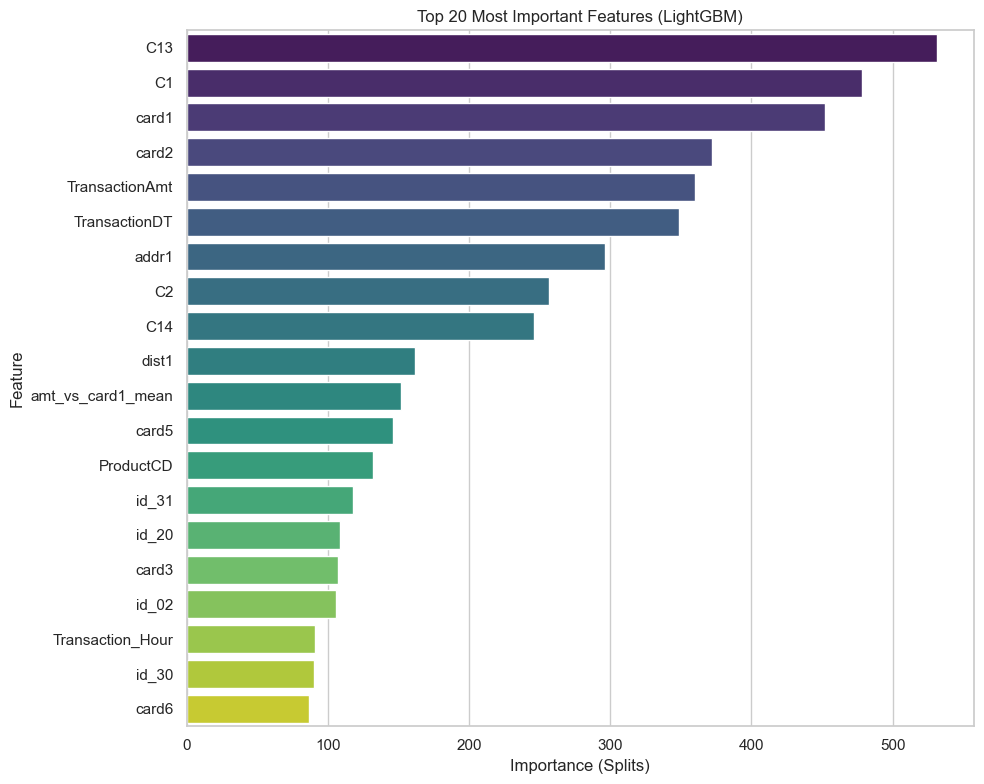

Importance of our engineered features:
- Transaction_Hour: Importance = 91
- Transaction_Day: Importance = 37
- Amt_is_Round: Importance = 65
- amt_vs_card1_mean: Importance = 152


In [33]:
# Plot the most important features from our LightGBM model
lgb_model = trained_models["LightGBM"]
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(20), palette='viridis')
plt.title('Top 20 Most Important Features (LightGBM)')
plt.xlabel('Importance (Splits)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Check if our interpretable features made the cut
print("Importance of our engineered features:")
for feat in ['Transaction_Hour', 'Transaction_Day', 'Amt_is_Round', 'amt_vs_card1_mean']:
    if feat in feature_importances['Feature'].values:
        rank = feature_importances[feature_importances['Feature'] == feat].index[0]
        imp = feature_importances.loc[rank, 'Importance']
        print(f"- {feat}: Importance = {imp}")

### 📌 Description: Explainability
By visualizing the Feature Importances, we can look exactly inside the "Black Box". This plot proves to the business stakeholders which features are heavily driving the fraud decisions. Furthermore, we output exactly how useful our engineered, interpretable features were for the model!